In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/Metro_Interstate_Traffic_Volume.csv")

In [3]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [4]:
df.shape

(48204, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [6]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [7]:
df.describe()
df.duplicated().sum()

np.int64(17)

In [8]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


## Next Step: Prepare the Date-Time Column

`date_time` is still stored as text, so we need to convert it into a proper datetime type before we can extract useful time-based features like hour, day of week, and month.

In [9]:
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.day_name()
df['month'] = df['date_time'].dt.month_name()
df['is_weekend'] = df['date_time'].dt.dayofweek >= 5

print(df['date_time'].dtype)
df[['date_time', 'hour', 'day_of_week', 'month', 'is_weekend']].head()

datetime64[ns]


,date_time,hour,day_of_week,month,is_weekend
0,2012-10-02 09:00:00,9,Tuesday,October,False
1,2012-10-02 10:00:00,10,Tuesday,October,False
2,2012-10-02 11:00:00,11,Tuesday,October,False
3,2012-10-02 12:00:00,12,Tuesday,October,False
4,2012-10-02 13:00:00,13,Tuesday,October,False


## Next Step: Clean Holiday and Duplicate Rows

The `holiday` column is mostly empty, so we should inspect it carefully and decide whether to convert it into a simpler binary feature. We should also verify whether the duplicate rows are exact duplicates before removing them.

In [10]:
holiday_counts = df['holiday'].value_counts(dropna=False)
df['is_holiday'] = df['holiday'].notna()
duplicate_count = df.duplicated().sum()

print('Holiday value counts:')
print(holiday_counts)
print('\nDuplicate rows:', duplicate_count)
print('\nSample duplicate rows:')
df[df.duplicated(keep=False)].head()

Holiday value counts:
holiday
NaN                          48143
Labor Day                        7
Christmas Day                    6
Thanksgiving Day                 6
Martin Luther King Jr Day        6
New Years Day                    6
Veterans Day                     5
Columbus Day                     5
Memorial Day                     5
Washingtons Birthday             5
State Fair                       5
Independence Day                 5
Name: count, dtype: int64

Duplicate rows: 17

Sample duplicate rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month,is_weekend,is_holiday
18696,NaN,286.290,0.0,0.0,1,Clear,sky is clear,2015-09-30 19:00:00,3679,19,Wednesday,September,False,False
18697,NaN,286.290,0.0,0.0,1,Clear,sky is clear,2015-09-30 19:00:00,3679,19,Wednesday,September,False,False
23850,NaN,289.060,0.0,0.0,90,Clouds,overcast clouds,2016-06-01 10:00:00,4831,10,Wednesday,June,False,False
23851,NaN,289.060,0.0,0.0,90,Clouds,overcast clouds,2016-06-01 10:00:00,4831,10,Wednesday,June,False,False
26783,NaN,289.775,0.0,0.0,56,Clouds,broken clouds,2016-09-21 15:00:00,5365,15,Wednesday,September,False,False


## Next Step: Visualize Traffic Volume

Now that the data is cleaned enough to inspect, we should look at the target distribution and check whether there are outliers or skewness in traffic volume.

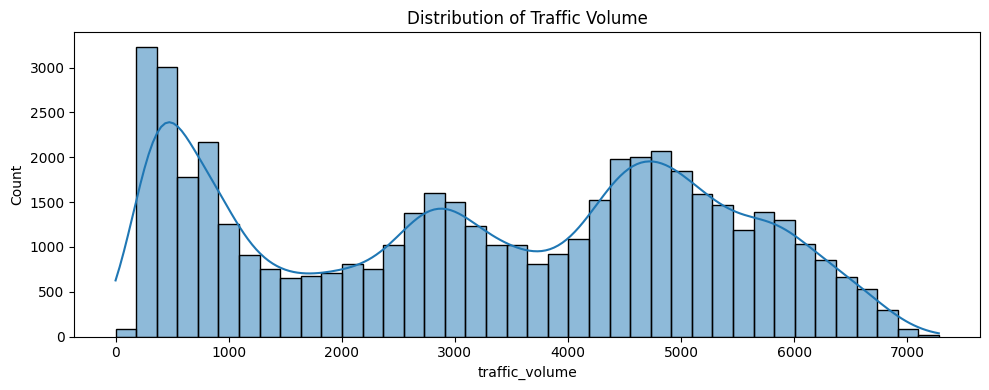

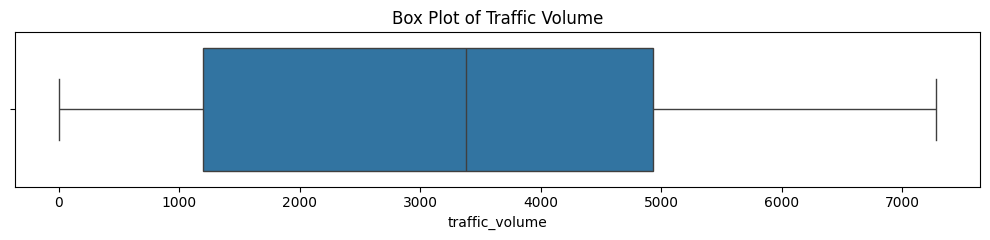

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.histplot(df['traffic_volume'], bins=40, kde=True)
plt.title('Distribution of Traffic Volume')
plt.xlabel('traffic_volume')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 2.5))
sns.boxplot(x=df['traffic_volume'])
plt.title('Box Plot of Traffic Volume')
plt.tight_layout()
plt.show()

## Next Step: Traffic Patterns by Time

The next useful question is when traffic rises and falls. We can answer that by looking at average traffic by hour, day of week, and month.

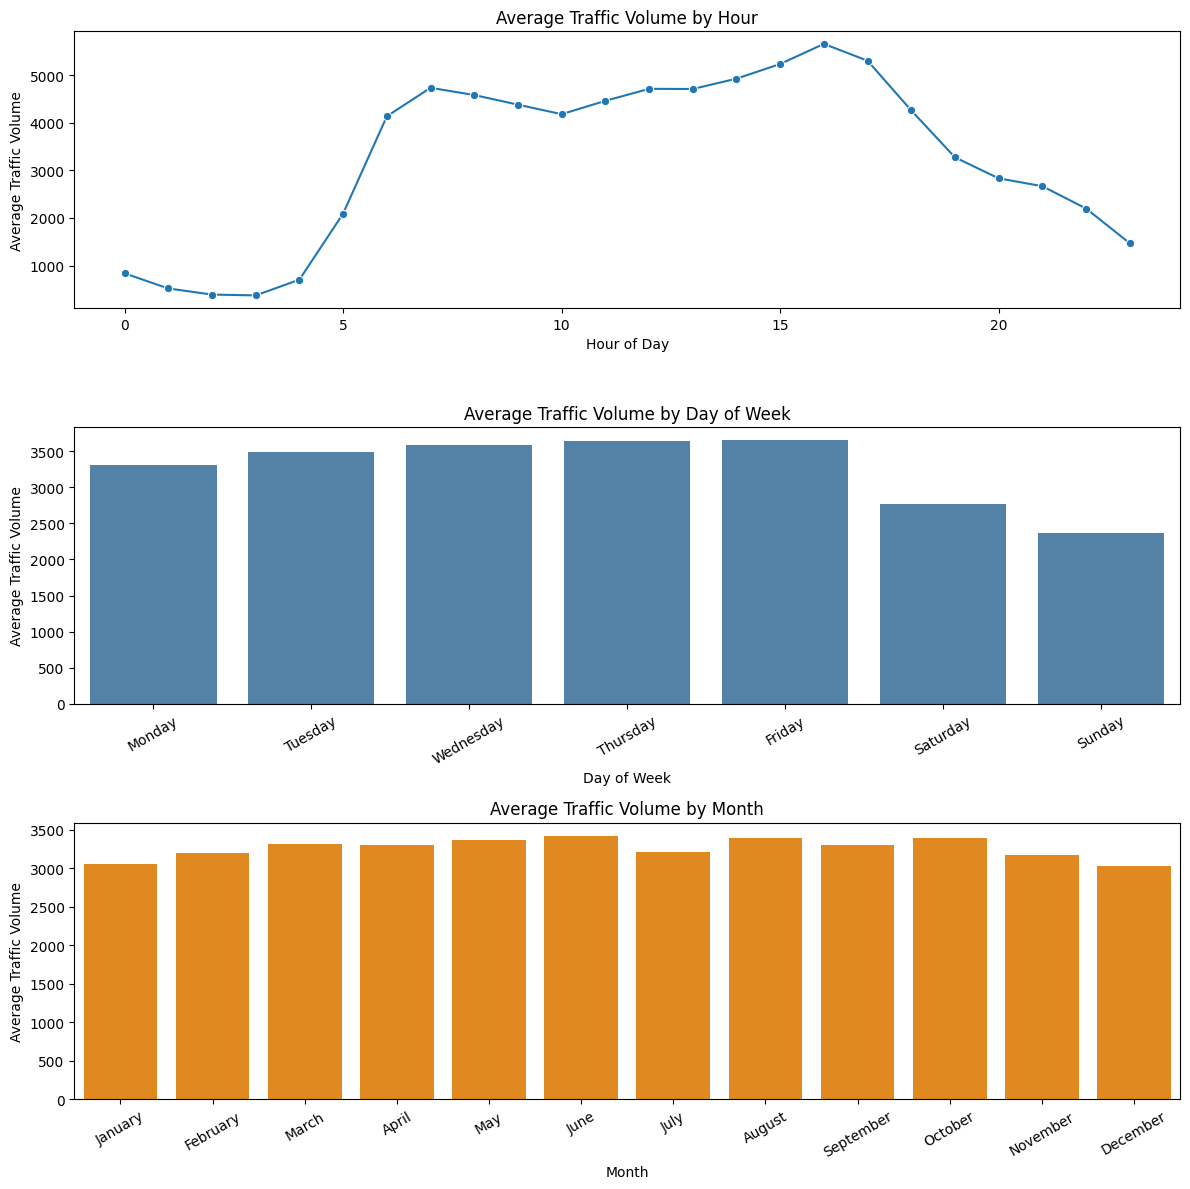

In [12]:
import calendar

hourly_avg = df.groupby('hour', as_index=False)['traffic_volume'].mean()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_avg = df.groupby('day_of_week', as_index=False)['traffic_volume'].mean()
day_avg['day_of_week'] = pd.Categorical(day_avg['day_of_week'], categories=day_order, ordered=True)
day_avg = day_avg.sort_values('day_of_week')

month_order = list(calendar.month_name)[1:]
month_avg = df.groupby('month', as_index=False)['traffic_volume'].mean()
month_avg['month'] = pd.Categorical(month_avg['month'], categories=month_order, ordered=True)
month_avg = month_avg.sort_values('month')

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

sns.lineplot(data=hourly_avg, x='hour', y='traffic_volume', marker='o', ax=axes[0])
axes[0].set_title('Average Traffic Volume by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Traffic Volume')

sns.barplot(data=day_avg, x='day_of_week', y='traffic_volume', ax=axes[1], color='steelblue')
axes[1].set_title('Average Traffic Volume by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Traffic Volume')
axes[1].tick_params(axis='x', rotation=30)

sns.barplot(data=month_avg, x='month', y='traffic_volume', ax=axes[2], color='darkorange')
axes[2].set_title('Average Traffic Volume by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Average Traffic Volume')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Next Step: Weather and Correlation Analysis

Weather is likely a secondary driver compared to time, but we should still check which weather conditions and numeric variables have the strongest relationship with traffic volume.

C:\Users\Vinutha\AppData\Local\Temp\ipykernel_3424\2021698532.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_main_avg, x='weather_main', y='traffic_volume', ax=axes[0], palette='viridis')
C:\Users\Vinutha\AppData\Local\Temp\ipykernel_3424\2021698532.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_desc_avg, y='weather_description', x='traffic_volume', ax=axes[1], palette='magma')


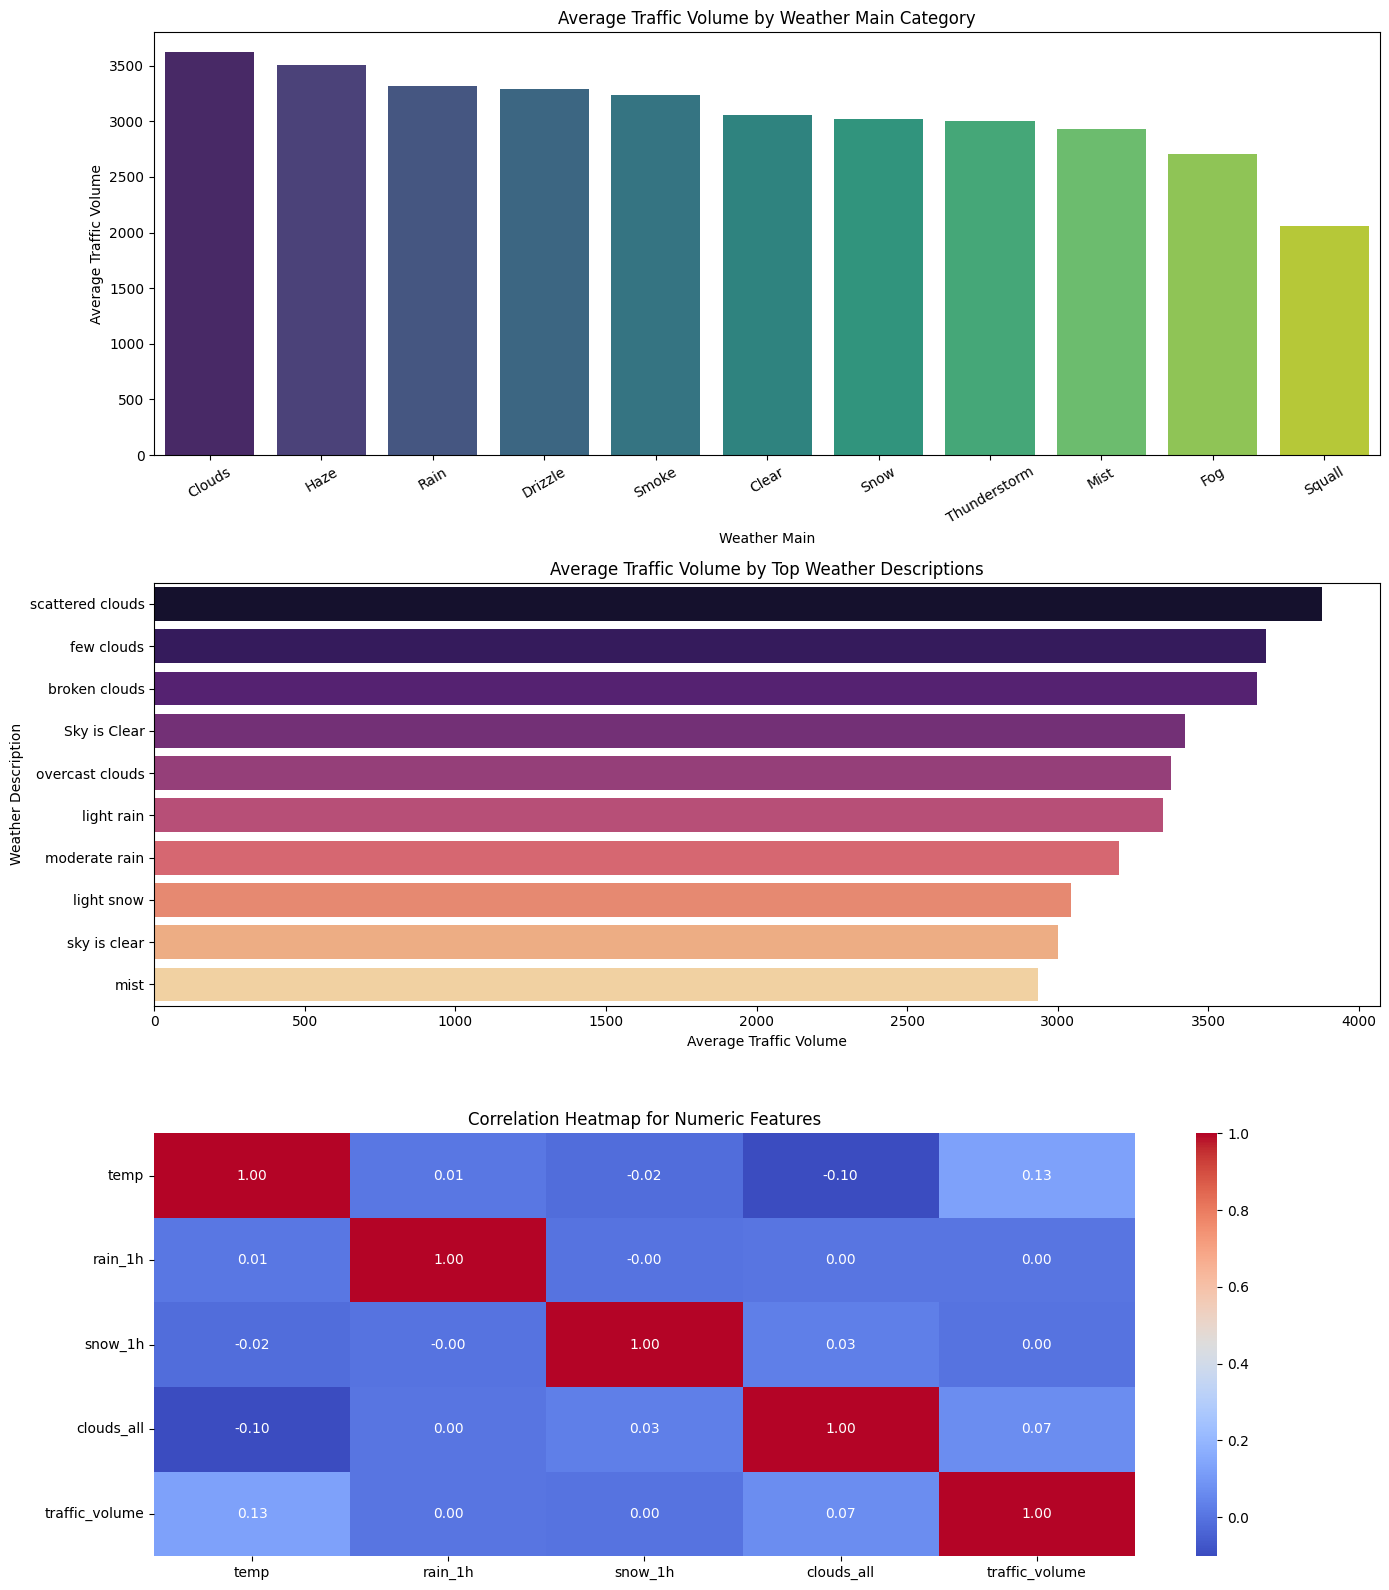

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Metro_Interstate_Traffic_Volume.csv')

weather_main_avg = df.groupby('weather_main', as_index=False)['traffic_volume'].mean().sort_values('traffic_volume', ascending=False)

weather_desc_counts = df['weather_description'].value_counts().head(10).index
weather_desc_avg = (
    df[df['weather_description'].isin(weather_desc_counts)]
    .groupby('weather_description', as_index=False)['traffic_volume']
    .mean()
    .sort_values('traffic_volume', ascending=False)
)

numeric_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']
correlation_matrix = df[numeric_cols].corr()

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

sns.barplot(data=weather_main_avg, x='weather_main', y='traffic_volume', ax=axes[0], palette='viridis')
axes[0].set_title('Average Traffic Volume by Weather Main Category')
axes[0].set_xlabel('Weather Main')
axes[0].set_ylabel('Average Traffic Volume')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=weather_desc_avg, y='weather_description', x='traffic_volume', ax=axes[1], palette='magma')
axes[1].set_title('Average Traffic Volume by Top Weather Descriptions')
axes[1].set_xlabel('Average Traffic Volume')
axes[1].set_ylabel('Weather Description')

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[2])
axes[2].set_title('Correlation Heatmap for Numeric Features')

plt.tight_layout()
plt.show()

## Next Step: Feature Engineering for Modeling

Now that we understand the raw patterns, we can build a clean model-ready table. The goal here is to keep useful time and weather signals while removing columns that would not help the model directly.

In [4]:
model_df = df.copy()

model_df['is_holiday'] = model_df['holiday'].notna().astype(int)
model_df['date_time'] = pd.to_datetime(model_df['date_time'])
model_df['hour'] = model_df['date_time'].dt.hour
model_df['day_of_week'] = model_df['date_time'].dt.day_name()
model_df['month'] = model_df['date_time'].dt.month_name()
model_df['is_weekend'] = (model_df['date_time'].dt.dayofweek >= 5).astype(int)

model_df = model_df.drop_duplicates().reset_index(drop=True)
model_df = model_df.drop(columns=['holiday', 'date_time', 'weather_description'])

categorical_cols = ['weather_main', 'hour', 'day_of_week', 'month']
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

print('Model-ready shape:', model_df.shape)
print('Columns:', len(model_df.columns))
model_df.head()

Model-ready shape: (48187, 57)
Columns: 57


,temp,rain_1h,snow_1h,clouds_all,traffic_volume,is_holiday,is_weekend,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,...,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
0,288.28,0.0,0.0,40,5545,0,0,True,False,False,...,False,False,False,False,False,False,False,False,True,False
1,289.36,0.0,0.0,75,4516,0,0,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,289.58,0.0,0.0,90,4767,0,0,True,False,False,...,False,False,False,False,False,False,False,False,True,False
3,290.13,0.0,0.0,90,5026,0,0,True,False,False,...,False,False,False,False,False,False,False,False,True,False
4,291.14,0.0,0.0,75,4918,0,0,True,False,False,...,False,False,False,False,False,False,False,False,True,False


## Next Step: Baseline Model Training

Now that we have a model-ready dataframe, we can split the data and train a simple baseline regression model. This gives us a performance reference before we try stronger models.

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = model_df.drop(columns=['traffic_volume'])
y = model_df['traffic_volume']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Baseline MAE: {mae:.2f}')
print(f'Baseline RMSE: {rmse:.2f}')
print(f'Baseline R2: {r2:.4f}')

Baseline MAE: 611.66
Baseline RMSE: 3330.97
Baseline R2: -1.7753


## Next Step: Decision Tree Benchmark

A decision tree can capture non-linear relationships that linear regression misses. We will use it as the first stronger baseline and compare the metrics fairly on the same test split.

In [7]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42, max_depth=12)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_r2 = r2_score(y_test, tree_pred)

print(f'Decision Tree MAE: {tree_mae:.2f}')
print(f'Decision Tree RMSE: {tree_rmse:.2f}')
print(f'Decision Tree R2: {tree_r2:.4f}')

Decision Tree MAE: 600.10
Decision Tree RMSE: 1023.09
Decision Tree R2: 0.7382


## Next Step: Random Forest Benchmark

Random Forest reduces the instability of a single decision tree by averaging many trees. This usually gives a stronger and more reliable baseline for tabular regression problems.

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f'Random Forest MAE: {rf_mae:.2f}')
print(f'Random Forest RMSE: {rf_rmse:.2f}')
print(f'Random Forest R2: {rf_r2:.4f}')

Random Forest MAE: 261.49
Random Forest RMSE: 462.45
Random Forest R2: 0.9465


## Next Step: Random Forest Tuning

The default Random Forest is already strong, so now we will tune a few important hyperparameters to see if we can improve generalization without overcomplicating the notebook.

In [9]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.7, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)
best_rf_model = rf_search.best_estimator_
best_rf_pred = best_rf_model.predict(X_test)
best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_pred))
best_rf_r2 = r2_score(y_test, best_rf_pred)

print('Best Parameters:', rf_search.best_params_)
print(f'Tuned Random Forest MAE: {best_rf_mae:.2f}')
print(f'Tuned Random Forest RMSE: {best_rf_rmse:.2f}')
print(f'Tuned Random Forest R2: {best_rf_r2:.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}
Tuned Random Forest MAE: 352.16
Tuned Random Forest RMSE: 554.19
Tuned Random Forest R2: 0.9232


## Next Step: Save the Best Model

The default Random Forest performed better than the tuned version, so we will save it as the final model candidate along with the feature columns needed for inference.

In [10]:
import joblib
from pathlib import Path

artifact_dir = Path('../artifacts')
artifact_dir.mkdir(parents=True, exist_ok=True)

final_model_path = artifact_dir / 'traffic_congestion_rf_model.joblib'
model_package = {
    'model': rf_model,
    'feature_columns': X.columns.tolist(),
    'target': 'traffic_volume',
    'metrics': {
        'mae': rf_mae,
        'rmse': rf_rmse,
        'r2': rf_r2
    }
}

joblib.dump(model_package, final_model_path)
print(f'Saved model package to: {final_model_path}')
print('Saved metrics:', model_package['metrics'])

Saved model package to: ..\artifacts\traffic_congestion_rf_model.joblib
Saved metrics: {'mae': 261.4870030200397, 'rmse': np.float64(462.4541756167072), 'r2': 0.9465062932950644}
